In [ ]:
import torch
import csv
from PIL import Image, ImageOps, ImageFilter
import random
from torchvision import transforms

beta = 0.001


def vector_to_image(tensor):
  transform = transforms.Compose([
      transforms.Normalize((0,), (2,)),
      transforms.Normalize((-0.5,), (1,)),
      transforms.ToPILImage()
  ])

  return transform(tensor)
def forward_process(x_0, t):

#   transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])
  # x_0 = transform(x_0)
  alpha = 1 - beta
  alpha_bar = alpha ** t

  eps = torch.randn(x_0.shape)
  x_t = alpha_bar ** .5 * x_0 + (1-alpha_bar) ** .5  * eps

  return x_t, eps

def forward_process_not_preprocessed(x_0, t):

  transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
  x_0 = transform(x_0)
  alpha = 1 - beta
  alpha_bar = alpha ** t

  eps = torch.randn(x_0.shape)
  x_t = alpha_bar ** .5 * x_0 + (1-alpha_bar) ** .5  * eps

  return x_t, eps

def backward_process(model, T, shape):
    x_t = torch.randn(3, shape[0], shape[1])

    for t in reversed(range(T)):
        eps_pred = model(x_t, t)


        alpha = 1 - beta
        alpha_bar = alpha ** t

        #from paper
        mu = 1 / alpha ** 0.5 * (x_t - (1- alpha)/((1 - alpha_bar) ** .5) * eps_pred)

        #adding back some noise
        z = torch.randn_like(x_t) if t > 0 else 0
        x_t = mu + beta**0.5 * z

    return x_t



In [12]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    block_out_channels=(64, 128, 256, 512),
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Params: {total_params}")

Total Trainable Params: 63482755


In [18]:
import os, glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import UNet2DModel
#Change IMG_SIZE to 512, 64 for testing

IMG_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class FaceDataset(Dataset):
    def __init__(self, root, transform=None):
        exts = ('*.jpg', '*.jpeg', '*.png', '*.webp')
        self.paths = []
        for e in exts:
            self.paths += glob.glob(os.path.join(root, '**', e), recursive=True)
        self.transform = transform
        if len(self.paths) == 0:
            raise RuntimeError(f"No images found under {root}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

dataset = FaceDataset(root='/content/output/faces_20260605_004211', transform=transform)
print(len(dataset), "images")

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

model = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=3,
    out_channels=3,
    block_out_channels=(64, 128, 256, 512),
)

330 images


In [9]:
!unzip output.zip

Archive:  output.zip
   creating: output/
   creating: output/faces_20260605_001106/
  inflating: output/faces_20260605_001106/face_000000.jpg  
  inflating: output/faces_20260605_001106/face_000001.jpg  
  inflating: output/faces_20260605_001106/face_000002.jpg  
  inflating: output/faces_20260605_001106/face_000003.jpg  
  inflating: output/faces_20260605_001106/face_000004.jpg  
  inflating: output/faces_20260605_001106/face_000005.jpg  
  inflating: output/faces_20260605_001106/face_000006.jpg  
  inflating: output/faces_20260605_001106/face_000007.jpg  
  inflating: output/faces_20260605_001106/face_000008.jpg  
  inflating: output/faces_20260605_001106/face_000009.jpg  
  inflating: output/faces_20260605_001106/face_000010.jpg  
  inflating: output/faces_20260605_001106/face_000011.jpg  
  inflating: output/faces_20260605_001106/face_000012.jpg  
  inflating: output/faces_20260605_001106/face_000013.jpg  
  inflating: output/faces_20260605_001106/face_000014.jpg  
  inflating: ou

In [ ]:
# Source - https://stackoverflow.com/a/56458316
# Posted by mao95, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-05, License - CC BY-SA 4.0

from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [19]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from diffusers import DDPMScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = AdamW(model.parameters(), lr=1e-4)

num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    running = 0.0
    for batch in dataloader:
        clean = batch.to(device)
        noise = torch.randn_like(clean)
        bs = clean.shape[0]

        # random timestep per image
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps, (bs,), device=device
        ).long()

        # forward diffusion: add noise to the clean images
        noisy = noise_scheduler.add_noise(clean, noise, timesteps)

        # model predicts the noise; loss is how close it got
        noise_pred = model(noisy, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()

    print(f"epoch {epoch+1}/{num_epochs}  loss {running/len(dataloader):.4f}")

epoch 1/100  loss 0.5407
epoch 2/100  loss 0.1705
epoch 3/100  loss 0.1204
epoch 4/100  loss 0.1051
epoch 5/100  loss 0.0832
epoch 6/100  loss 0.0890
epoch 7/100  loss 0.0733
epoch 8/100  loss 0.0590
epoch 9/100  loss 0.0622
epoch 10/100  loss 0.0600
epoch 11/100  loss 0.0515
epoch 12/100  loss 0.0452
epoch 13/100  loss 0.0578
epoch 14/100  loss 0.0541
epoch 15/100  loss 0.0430
epoch 16/100  loss 0.0521
epoch 17/100  loss 0.0494
epoch 18/100  loss 0.0471
epoch 19/100  loss 0.0397
epoch 20/100  loss 0.0390
epoch 21/100  loss 0.0356
epoch 22/100  loss 0.0438
epoch 23/100  loss 0.0366
epoch 24/100  loss 0.0327
epoch 25/100  loss 0.0371
epoch 26/100  loss 0.0413
epoch 27/100  loss 0.0288
epoch 28/100  loss 0.0344
epoch 29/100  loss 0.0314
epoch 30/100  loss 0.0317
epoch 31/100  loss 0.0384
epoch 32/100  loss 0.0223
epoch 33/100  loss 0.0274
epoch 34/100  loss 0.0271
epoch 35/100  loss 0.0267
epoch 36/100  loss 0.0307
epoch 37/100  loss 0.0262
epoch 38/100  loss 0.0209
epoch 39/100  loss 0.

  0%|          | 0/1000 [00:00<?, ?it/s]

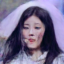

In [20]:
from diffusers import DDPMPipeline

pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler).to(device)
images = pipeline(batch_size=4).images   # returns 4 PIL images

for i, img in enumerate(images):
    img.save(f"sample_{i}.png")
images[0]   # displays inline in Colab

In [21]:
import os
from google.colab import drive
drive.mount('/content/drive')   # skip if already mounted

CKPT_DIR = '/content/drive/MyDrive/ddpm-faces'
os.makedirs(CKPT_DIR, exist_ok=True)

model.save_pretrained(os.path.join(CKPT_DIR, 'final-model'))
print("saved to", os.path.join(CKPT_DIR, 'final-model'))

Mounted at /content/drive
saved to /content/drive/MyDrive/ddpm-faces/final-model
